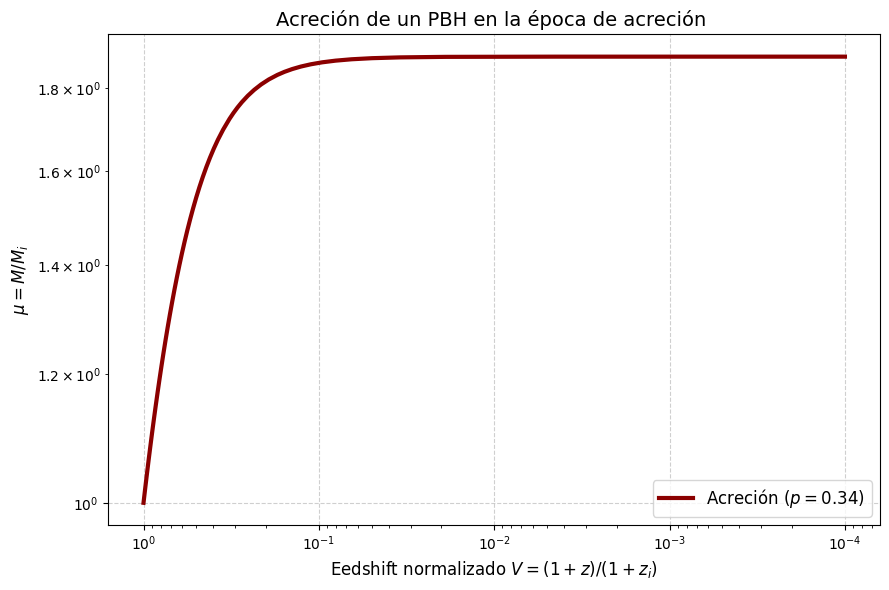

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#ERA DE RADIACIÓN
# ---------------------------------------------------------
# Parámetros del Modelo Normalizado
# ---------------------------------------------------------
f = 0.7257
p = 0.34  # Fracción de masa inicial (Debe ser menor a 'f')
z_i= 1e8
z_f= 1e4

# Parámetros del PBH
G = 6.67430e-8        # cm^3 g^-1 s^-2 (Antes e-11)
c = 2.998e10          # cm/s (Antes e8)
M_sol = 1.989e33      # g (Masa solar en gramos)
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)

# Convertir H0 a 1/s (CGS)
# 1 km = 10^5 cm
# 1 Mpc = 3.086e24 cm
H0 = (H0_km_s_Mpc * 1e5) / 3.086e24 

Omega_r0 = 9.0e-5     

v_inf = c / np.sqrt(3)

# ---------------------------------------------------------
# Ecuación Diferencial (Acreción Pura) CORREGIDA
# ---------------------------------------------------------
def dmu_dV(V, mu):
    """
    Ecuación (1) de los apuntes: dmu/dV = - (2p/f) * mu^2 * V
    """
    # Blindaje contra listas/arrays
    mu_val = np.atleast_1d(mu)[0]
    
    # CORRECCIÓN: Devolvemos una LISTA, no un número suelto
    return [- (2 * p / f) * (mu_val**2) * V]

# ---------------------------------------------------------
# Ejecución
# ---------------------------------------------------------
V_i = 1.0    # Presente al momento de formación (z = z_i)
V_f = (1.0 + z_f)/(1.0 + z_i)   # Futuro lejano (z mucho menor a z_i)

sol = solve_ivp(
    dmu_dV,
    [V_i, V_f],
    [1.0],       # La masa inicial normalizada es exactamente 1
    method='Radau',
    dense_output=True,
    rtol=1e-8,
    atol=1e-10
)

# ---------------------------------------------------------
# Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

plt.loglog(sol.t, sol.y[0], color='darkred', lw=3, label=f'Acreción ($p={p}$)')

# Invertimos el eje X porque V va de 1 (pasado) a 0 (futuro)
plt.gca().invert_xaxis()

plt.xlabel(r'Eedshift normalizado $V = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'$\mu= M/M_i$', fontsize=12)
plt.title('Acreción de un PBH en la época de acreción ', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

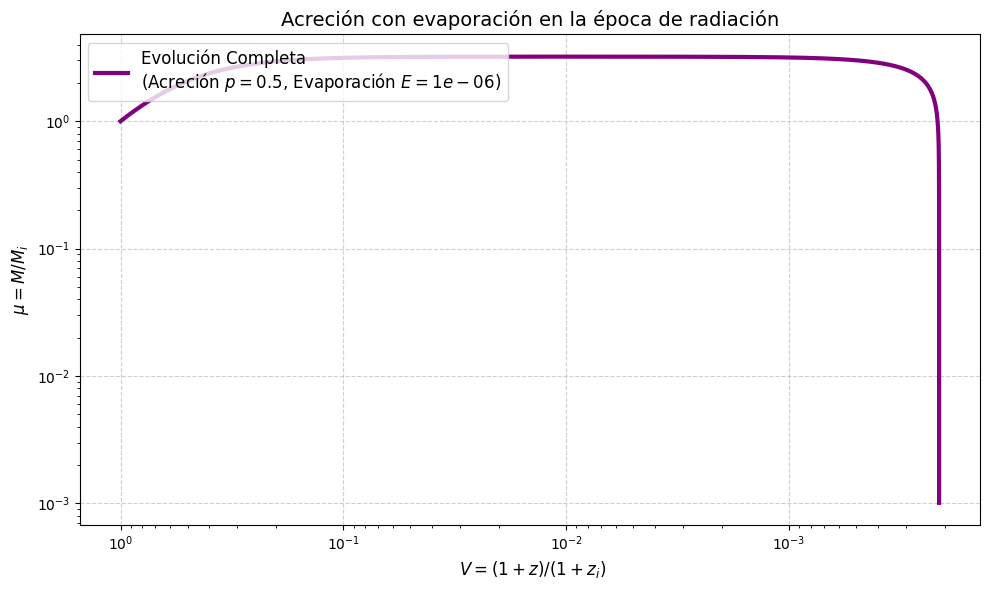

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# Parámetros del Modelo Normalizado
# ---------------------------------------------------------
f = 0.7257
p = 0.5  # Término de fuerza de acreción
z_i= 1e8
z_f= 1e4
# Parámetros del PBH
G = 6.67430e-8        # cm^3 g^-1 s^-2 (Antes e-11)
c = 2.998e10          # cm/s (Antes e8)
hbar = 1.05457e-27 
M_sol = 1.989e33      # g (Masa solar en gramos)
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)
H0 = (67.4 * 1e5) / 3.0857e24 
Omega_r0 = 9.0e-5
K=(hbar*(c**4))/(3840*np.pi*(G**2))
E=1e-6
# ---------------------------------------------------------
# Ecuación Diferencial (Acreción + Evaporación)
# ---------------------------------------------------------
def dmu_dV_completa(V, mu):
    mu_val = mu[0]
    
    # Prevenir división por cero si la masa se hace negativa
    if mu_val <= 1e-10:
        return [0.0]
    
    # Término 1: Acreción (Crece la masa)
    acrecion = - (2 * p / f) * (mu_val**2) * V
    
    # Término 2: Evaporación (Reduce la masa)
    evaporacion = (E) / ((V**3) * (mu_val**2))
    
    return [acrecion + evaporacion]

# Evento para detener la integración cuando el PBH se evapora (mu = 0)
def pbh_evaporado(V, mu):
    return mu[0] - 1e-3
pbh_evaporado.terminal = True
pbh_evaporado.direction = -1

# ---------------------------------------------------------
# Ejecución
# ---------------------------------------------------------
V_i = 1.0    # Inicio (Formación)
V_f = (1.0 + z_f)/(1.0 + z_i)  # Futuro lejano 

sol = solve_ivp(
    dmu_dV_completa,
    [V_i, V_f],
    [1.0],       # Masa inicial normalizada
    method='Radau',
    events=pbh_evaporado,
    rtol=1e-8,
    atol=1e-10
)

# Insertar un NaN al final para que la gráfica corte abruptamente en la evaporación
V_sol = np.append(sol.t, sol.t[-1] - 1e-5)
mu_sol = np.append(sol.y[0], np.nan)

# ---------------------------------------------------------
# Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.loglog(V_sol, mu_sol, color='purple', lw=3, label=f'Evolución Completa\n(Acreción $p={p}$, Evaporación $E={E}$)')

plt.gca().invert_xaxis()

plt.xlabel(r' $V = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'$\mu = M/M_i$', fontsize=12)
plt.title('Acreción con evaporación en la época de radiación', fontsize=14)

# Anotaciones explicativas

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

--------------------------------------------------
Redshift inicial (z_i): 1.0e+08
Tiempo de formación (t_i): 2.41e+03 segundos
Masa inicial (M_i): 7.01e+41 gramos
Constante calculada E: 2.21742e-97
--------------------------------------------------


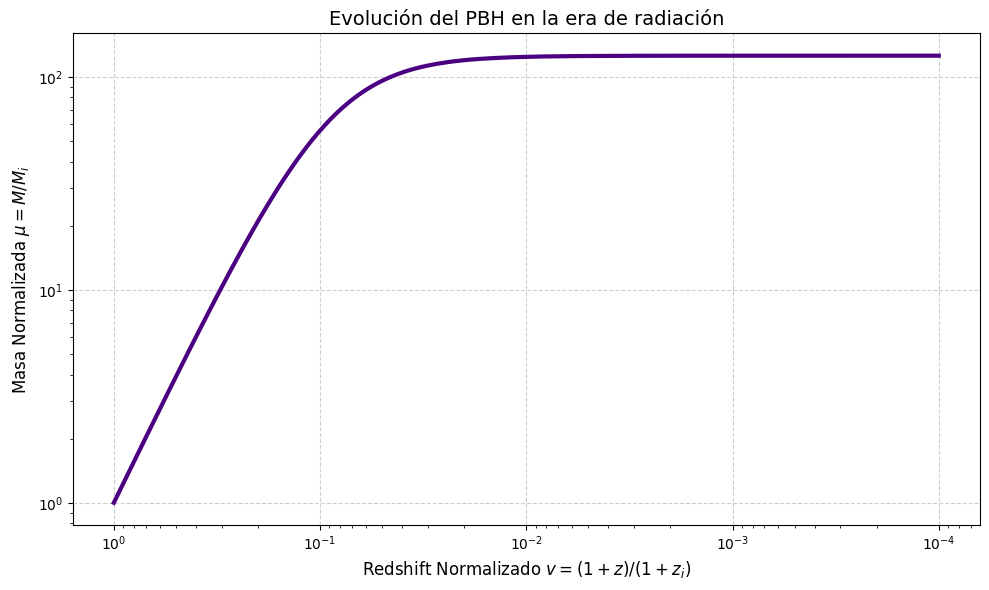

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#E calculado físicamente

# ---------------------------------------------------------
# 1. Constantes Físicas Universales (CGS)
# ---------------------------------------------------------
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_r0 = 9.0e-5     

# ---------------------------------------------------------
# 2. Parámetros del Agujero Negro (Física de Formación)
# ---------------------------------------------------------
# Redshift de formación (z_i muy alto para que la masa sea ligera y logre evaporarse)
z_i = 1e8  
z_f=1e4
p = 0.72  

# f = (8*sqrt(2)/3) * (c_inf / c)^3, donde c_inf = c/sqrt(3)
f = (8 * np.sqrt(2) / 3) * (1 / np.sqrt(3))**3 # Aprox 0.725774


# Tiempo físico de formación (t_i) en era de radiación
t_i = 1.0 / (2 * H0 * np.sqrt(Omega_r0) * (1 + z_i)**2)

# Masa del horizonte al tiempo t_i
M_Hi = (c**3 * t_i) / G
M_c=f*M_Hi

# Masa inicial del PBH
M_i = (p/f) * M_c

# Constante de evaporación K
K = (hbar * c**4) / (3840 * np.pi * G**2)

# ¡Cálculo de E derivado en tu ecuación diferencial!
E = (2 * K * t_i) / (M_i**3)

print("-" * 50)
print(f"Redshift inicial (z_i): {z_i:.1e}")
print(f"Tiempo de formación (t_i): {t_i:.2e} segundos")
print(f"Masa inicial (M_i): {M_i:.2e} gramos")
print(f"Constante calculada E: {E:.5e}")
print("-" * 50)

# ---------------------------------------------------------
# 4. Ecuación Diferencial (Ecuación 2 de los apuntes)
# ---------------------------------------------------------
def dmu_dv(v, mu):
    mu_val = np.atleast_1d(mu)[0]
    
    if mu_val <= 1e-5:
        return [0.0]
    
    term_evap = E / ((v**3) * (mu_val**2))
    term_acc = (2 * p / f) * (mu_val**2) * v
    
    return [term_evap - term_acc]

# Evento para detener la integración cuando el PBH se evapora
def evaporacion_total(v, mu):
    return mu[0] - 1e-3  
evaporacion_total.terminal = True
evaporacion_total.direction = -1

# ---------------------------------------------------------
# 5. Ejecución del Solucionador
# ---------------------------------------------------------
v_i = 1.0    
v_f = (1.0 + z_f)/(1.0 + z_i)  

sol = solve_ivp(
    dmu_dv,
    [v_i, v_f],
    [1.0],       
    method='Radau',
    events=evaporacion_total,
    rtol=1e-8,
    atol=1e-10
)

# Corte visual limpio
v_sol = np.append(sol.t, sol.t[-1] - 1e-11)
mu_sol = np.append(sol.y[0], np.nan)

# ---------------------------------------------------------
# 6. Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.loglog(v_sol, mu_sol, color='indigo', lw=3, label=f'Ecuación (2)\n$p={p}$, $E={E:.1e}$')

plt.gca().invert_xaxis()

plt.xlabel(r'Redshift Normalizado $v = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M/M_i$', fontsize=12)
plt.title('Evolución del PBH en la era de radiación', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

<>:113: SyntaxWarning: invalid escape sequence '\g'
<>:113: SyntaxWarning: invalid escape sequence '\g'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_29576\1785833722.py:113: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Evolución normalizada en la era de materia ($\gamma=5/3$)', fontsize=14)


--------------------------------------------------
Redshift inicial (z_i): 3100.0
Tiempo de inicio (t_i): 3.15e+12 s
Masa inicial (M_i): 7.01e+33 g
Coeficiente Acreción (A_mat): 2.971e-04
Coeficiente Evaporación (E_mat): 2.174e-64
--------------------------------------------------


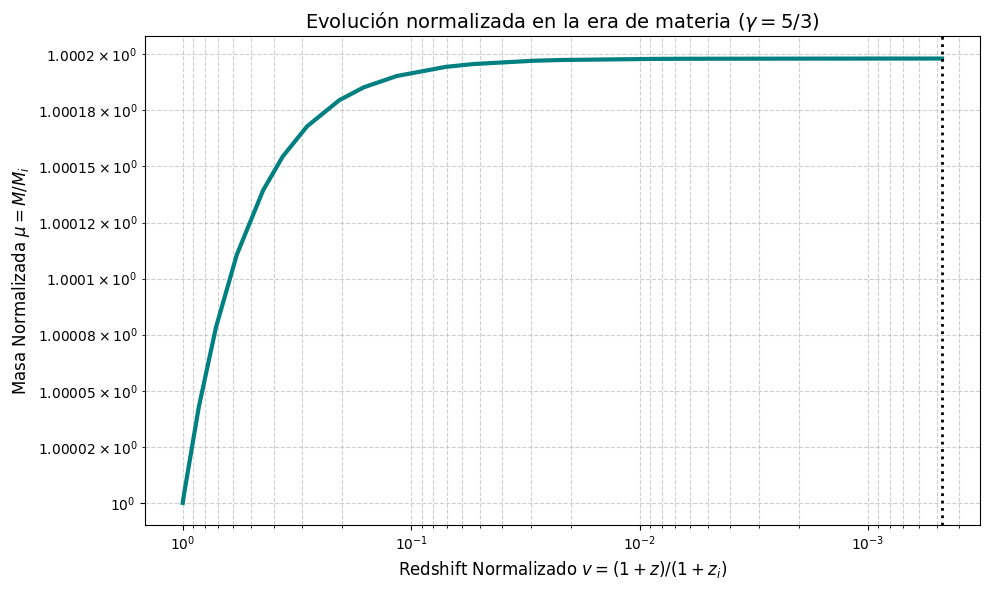

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# 1. Constantes Físicas Universales (CGS)
# ---------------------------------------------------------
G = 6.67430e-8        
c = 2.99792e10        
hbar = 1.05457e-27    
M_sol = 1.989e33
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 

# Cambio 1: Ahora usamos la densidad de Materia
Omega_m0 = 0.315      

# ---------------------------------------------------------
# 2. Configuración de la Era de Materia
# ---------------------------------------------------------
# Cambio 2: Empezamos en la igualdad materia-radiación
z_i = 3100.0  
z_f = 0.47     # Evolucionamos hasta el presente

# Velocidad del gas frío (~5 km/s)
v_inf = 5e5 

# Masa inicial al entrar a la era de materia (ej. 100 Masas Solares)
M_i = 7.01e33

# ---------------------------------------------------------
# 3. Cálculo de Coeficientes para Materia
# ---------------------------------------------------------
# Cambio 3: Nueva fórmula del tiempo en era de materia
t_i = (2.0 / 3.0) / (H0 * np.sqrt(Omega_m0) * (1 + z_i)**1.5)

# Constante de evaporación K
K = (hbar * c**4) / (3840 * np.pi * G**2)

# Cambio 4: Coeficientes A_mat y E_mat deducidos para gamma = 5/3
A_mat = (3 * G * M_i * H0 * np.sqrt(Omega_m0) * (1 + z_i)**1.5) / (8 * v_inf**3)
E_mat = K / (M_i**3 * H0 * np.sqrt(Omega_m0) * (1 + z_i)**1.5)

print("-" * 50)
print(f"Redshift inicial (z_i): {z_i}")
print(f"Tiempo de inicio (t_i): {t_i:.2e} s")
print(f"Masa inicial (M_i): {M_i:.2e} g")
print(f"Coeficiente Acreción (A_mat): {A_mat:.3e}")
print(f"Coeficiente Evaporación (E_mat): {E_mat:.3e}")
print("-" * 50)

# ---------------------------------------------------------
# 4. Ecuación Diferencial (Era de Materia)
# ---------------------------------------------------------
def dmu_dv_materia(v, mu):
    mu_val = np.atleast_1d(mu)[0]
    
    if mu_val <= 1e-5:
        return [0.0]
    
    # Cambio 5: Nuevas potencias de v (2.5 para evap, 0.5 para acc)
    term_evap = E_mat / ((v**2.5) * (mu_val**2))
    term_acc = A_mat * (mu_val**2) * np.sqrt(v)
    
    return [term_evap - term_acc]

# --- Eventos de Parada ---
def evaporacion_total(v, mu):
    return mu[0] - 1e-3  
evaporacion_total.terminal = True
evaporacion_total.direction = -1

# Si crece 10,000 veces su tamaño, detenemos para no colapsar la gráfica
def crecimiento_extremo(v, mu):
    return mu[0] - 1e4 
crecimiento_extremo.terminal = True
crecimiento_extremo.direction = 1

# ---------------------------------------------------------
# 5. Ejecución del Solucionador
# ---------------------------------------------------------
v_i = 1.0    
v_f = (1.0 + z_f) / (1.0 + z_i) 

sol = solve_ivp(
    dmu_dv_materia,
    [v_i, v_f],
    [1.0],       
    method='Radau',
    events=[evaporacion_total, crecimiento_extremo],
    rtol=1e-9,
    atol=1e-12
)

# Limpieza para gráfica
v_sol = sol.t
mu_sol = sol.y[0]
if sol.status == 1 and mu_sol[-1] < 1e-2:
    v_sol = np.append(v_sol, v_sol[-1] - 1e-6)
    mu_sol = np.append(mu_sol, np.nan)

# ---------------------------------------------------------
# 6. Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Usamos loglog porque el crecimiento es masivo
plt.loglog(v_sol, mu_sol, color='teal', lw=3, label=f'Masa: {M_i/M_sol:.0f} $M_\\odot$')

plt.gca().invert_xaxis()
plt.xlabel(r'Redshift Normalizado $v = (1+z)/(1+z_i)$', fontsize=12)
plt.ylabel(r'Masa Normalizada $\mu = M/M_i$', fontsize=12)
plt.title('Evolución normalizada en la era de materia ($\gamma=5/3$)', fontsize=14)
#.xlim(1+1e-10,1-5e-10)
plt.axvline(x=v_f, color='black', linestyle=':', lw=2, label='Presente ($z=0$)')

plt.grid(True, linestyle='--', alpha=0.6, which='both')
#plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()